# ML with Bayesian Hyperparameter Optimization (Optuna)

We use **Optuna** to find the best hyperparameters for Random Forest, Gradient Boosting, and Extra Trees models predicting **`household_income_total`** from the 27 research features (after hybrid scaling).

After optimization we evaluate each model with:
- R², MAE, RMSE on the held-out test set
- Predicted vs. Actual scatter plot
- Residual plot
- Unified normalized feature importance comparison

## 1. Setup — data load, hybrid scaling

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

PROJECT_ROOT = Path('..').resolve()
RESEARCH_CSV = PROJECT_ROOT / 'data' / 'ilcs' / 'research' / 'ml_households_research_columns_imputed.csv'
OUT_DIR = PROJECT_ROOT / 'data' / 'ilcs' / 'research' / 'bayesian_opt'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'household_income_total'
df = pd.read_csv(RESEARCH_CSV, low_memory=False)
_EXCLUDE = {TARGET, 'interview_month'}
feature_cols = [c for c in df.columns if c not in _EXCLUDE and np.issubdtype(df[c].dtype, np.number)]
X = df[feature_cols]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Hybrid scaling (same as feature importance notebook) ────────────────
_LOG_STD = [
    'potable_water_hours_day', 'heating_spend_last_winter_amd', 'family_debt_amount',
    'money_family_need_monthly_live', 'drm_in_amd', 'money_family_need_monthly_make',
    'amd_3', 'food_purchases_total', 'services_goods_total', 'goods_services_total',
]
_ROBUST = [
    'household_size', 'dwelling_ownership', 'number_of_rooms', 'has_other_dwelling',
    'dwelling_condition_estimate', 'registered_poverty_benefit',
    'share_families_really_vulnerable', 'household_income_source_count',
]
_MINMAX = [
    'has_computer', 'household_has_car', 'dwelling_renovated', 'building_new_house',
    'household_sent_money_goods_12m', 'household_received_money_goods_12m',
    'lent_money_12m', 'borrowed_money_12m', 'humanitarian_assistance_12m',
]

def _fit_hybrid(X_df):
    scalers = {}
    ls = [c for c in _LOG_STD if c in X_df.columns]
    rb = [c for c in _ROBUST  if c in X_df.columns]
    mm = [c for c in _MINMAX  if c in X_df.columns]
    if ls: scalers['log_std'] = (StandardScaler().fit(np.log1p(X_df[ls].values)), ls)
    if rb: scalers['robust']  = (RobustScaler().fit(X_df[rb].values), rb)
    if mm: scalers['minmax']  = (MinMaxScaler().fit(X_df[mm].values), mm)
    return scalers

def _transform_hybrid(X_df, scalers):
    out = X_df.copy().astype(float)
    for key, (sc, cols) in scalers.items():
        out[cols] = sc.transform(np.log1p(X_df[cols].values) if key == 'log_std' else X_df[cols].values)
    return out.values

_scalers = _fit_hybrid(X_train)
X_train_s = _transform_hybrid(X_train, _scalers)
X_test_s  = _transform_hybrid(X_test,  _scalers)

BEST_MODELS   = {}  # name → fitted model
BEST_PARAMS   = {}  # name → best params
MODEL_METRICS = {}  # name → {R², MAE, RMSE}
IMPORTANCES   = {}  # name → importance array

print(f'Features: {len(feature_cols)} | Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Hybrid scaling applied: log1p+Std / Robust / MinMax')

Features: 27 | Train: 4,147 | Test: 1,037
Hybrid scaling applied: log1p+Std / Robust / MinMax


## 2. Random Forest — Bayesian optimization (Optuna, 50 trials, 5-fold CV)

In [2]:
def _rf_objective(trial):
    params = dict(
        n_estimators    = trial.suggest_int('n_estimators', 50, 400),
        max_depth       = trial.suggest_int('max_depth', 3, 20),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features    = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
        random_state=42, n_jobs=-1,
    )
    model = RandomForestRegressor(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(_rf_objective, n_trials=50, show_progress_bar=True)

BEST_PARAMS['RF'] = study_rf.best_params
print(f'\nRF best CV R²: {study_rf.best_value:.4f}')
print(f'Best params: {study_rf.best_params}')

best_rf = RandomForestRegressor(**{**study_rf.best_params, 'random_state': 42, 'n_jobs': -1})
best_rf.fit(X_train_s, y_train)
BEST_MODELS['RF'] = best_rf
IMPORTANCES['RF'] = best_rf.feature_importances_

y_pred = best_rf.predict(X_test_s)
MODEL_METRICS['RF'] = dict(R2=r2_score(y_test, y_pred),
                            MAE=mean_absolute_error(y_test, y_pred),
                            RMSE=np.sqrt(mean_squared_error(y_test, y_pred)))
print(f"Test — R²: {MODEL_METRICS['RF']['R2']:.4f} | MAE: {MODEL_METRICS['RF']['MAE']:,.0f} | RMSE: {MODEL_METRICS['RF']['RMSE']:,.0f} AMD")

Best trial: 27. Best value: 0.429523:  86%|████████▌ | 43/50 [01:03<00:08,  1.28s/it]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propaga


RF best CV R²: 0.4295
Best params: {'n_estimators': 290, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.7}
Test — R²: 0.3578 | MAE: 82,724 | RMSE: 162,605 AMD


## 3. Gradient Boosting — Bayesian optimization

In [3]:
def _gbm_objective(trial):
    params = dict(
        n_estimators   = trial.suggest_int('n_estimators', 50, 400),
        max_depth      = trial.suggest_int('max_depth', 2, 8),
        learning_rate  = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        subsample      = trial.suggest_float('subsample', 0.6, 1.0),
        max_features   = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        random_state=42,
    )
    model = GradientBoostingRegressor(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

study_gbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_gbm.optimize(_gbm_objective, n_trials=50, show_progress_bar=True)

BEST_PARAMS['GBM'] = study_gbm.best_params
print(f'\nGBM best CV R²: {study_gbm.best_value:.4f}')
print(f'Best params: {study_gbm.best_params}')

best_gbm = GradientBoostingRegressor(**{**study_gbm.best_params, 'random_state': 42})
best_gbm.fit(X_train_s, y_train)
BEST_MODELS['GBM'] = best_gbm
IMPORTANCES['GBM'] = best_gbm.feature_importances_

y_pred = best_gbm.predict(X_test_s)
MODEL_METRICS['GBM'] = dict(R2=r2_score(y_test, y_pred),
                             MAE=mean_absolute_error(y_test, y_pred),
                             RMSE=np.sqrt(mean_squared_error(y_test, y_pred)))
print(f"Test — R²: {MODEL_METRICS['GBM']['R2']:.4f} | MAE: {MODEL_METRICS['GBM']['MAE']:,.0f} | RMSE: {MODEL_METRICS['GBM']['RMSE']:,.0f} AMD")

Best trial: 31. Best value: 0.450952: 100%|██████████| 50/50 [00:46<00:00,  1.07it/s]



GBM best CV R²: 0.4510
Best params: {'n_estimators': 372, 'max_depth': 7, 'learning_rate': 0.022460169207691574, 'min_samples_split': 11, 'min_samples_leaf': 6, 'subsample': 0.9103728065338949, 'max_features': 'sqrt'}
Test — R²: 0.3690 | MAE: 81,339 | RMSE: 161,173 AMD


In [ ]:
trials = study_gbm.trials
trial_nums = [t.number for t in trials]
trial_vals = [t.value for t in trials]
best_so_far = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(trial_nums, trial_vals, alpha=0.5, s=20, label='Trial R²', color='darkgreen')
ax.plot(trial_nums, best_so_far, color='black', linewidth=1.5, label='Best so far')
ax.set_xlabel('Trial')
ax.set_ylabel('CV R²')
ax.set_title('Optuna GBM — Optimization History (50 trials)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'optuna-gb-history.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Extra Trees — Bayesian optimization

In [4]:
def _et_objective(trial):
    params = dict(
        n_estimators    = trial.suggest_int('n_estimators', 50, 400),
        max_depth       = trial.suggest_int('max_depth', 3, 25),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features    = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
        random_state=42, n_jobs=-1,
    )
    model = ExtraTreesRegressor(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

study_et = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_et.optimize(_et_objective, n_trials=50, show_progress_bar=True)

BEST_PARAMS['ExtraTrees'] = study_et.best_params
print(f'\nET best CV R²: {study_et.best_value:.4f}')
print(f'Best params: {study_et.best_params}')

best_et = ExtraTreesRegressor(**{**study_et.best_params, 'random_state': 42, 'n_jobs': -1})
best_et.fit(X_train_s, y_train)
BEST_MODELS['ExtraTrees'] = best_et
IMPORTANCES['ExtraTrees'] = best_et.feature_importances_

y_pred = best_et.predict(X_test_s)
MODEL_METRICS['ExtraTrees'] = dict(R2=r2_score(y_test, y_pred),
                                    MAE=mean_absolute_error(y_test, y_pred),
                                    RMSE=np.sqrt(mean_squared_error(y_test, y_pred)))
print(f"Test — R²: {MODEL_METRICS['ExtraTrees']['R2']:.4f} | MAE: {MODEL_METRICS['ExtraTrees']['MAE']:,.0f} | RMSE: {MODEL_METRICS['ExtraTrees']['RMSE']:,.0f} AMD")

Best trial: 36. Best value: 0.418217: 100%|██████████| 50/50 [00:42<00:00,  1.18it/s]



ET best CV R²: 0.4182
Best params: {'n_estimators': 202, 'max_depth': 23, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 0.5}
Test — R²: 0.3392 | MAE: 83,778 | RMSE: 164,934 AMD


## 5. Model metrics comparison

════════════════════════════════════════════════════════════
MODEL PERFORMANCE — Bayesian Optimized (target: household_income_total)
════════════════════════════════════════════════════════════
                R²  MAE (AMD)  RMSE (AMD)
Model                                    
RF          0.3578    82724.0    162605.0
GBM         0.3690    81339.0    161173.0
ExtraTrees  0.3392    83778.0    164934.0

All metrics on held-out test set (20% of 5,184 households)


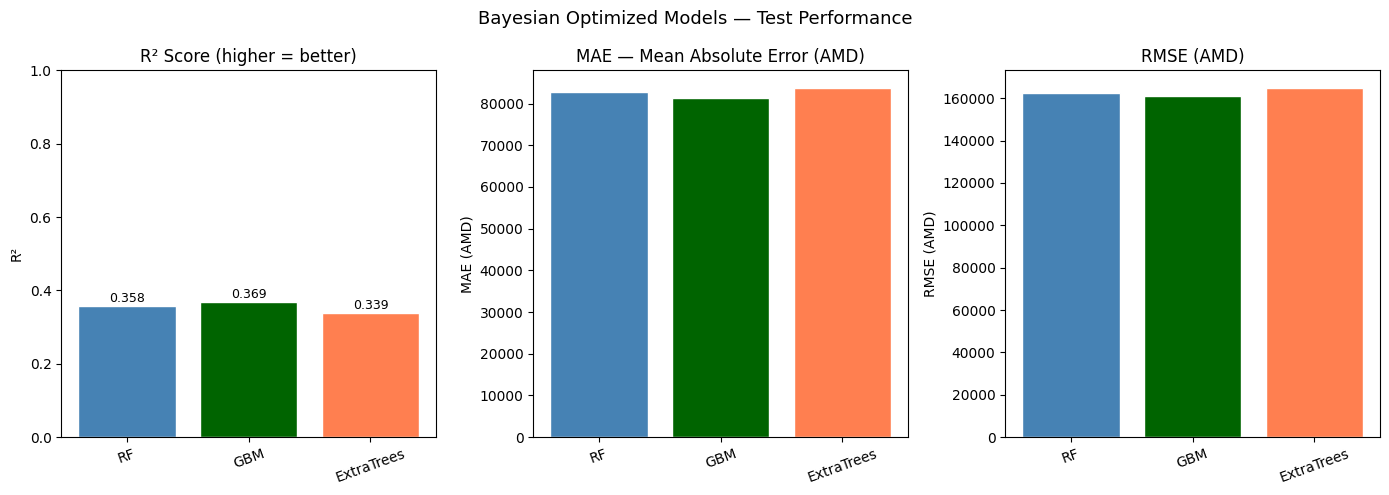

In [5]:
metrics_df = pd.DataFrame(MODEL_METRICS).T.rename_axis('Model')
metrics_df.columns = ['R²', 'MAE (AMD)', 'RMSE (AMD)']
metrics_df = metrics_df.round({'R²': 4, 'MAE (AMD)': 0, 'RMSE (AMD)': 0})

# Save best params
pd.DataFrame(BEST_PARAMS).to_csv(OUT_DIR / 'best_params.csv')
metrics_df.to_csv(OUT_DIR / 'model_metrics.csv')

print('═' * 60)
print('MODEL PERFORMANCE — Bayesian Optimized (target: household_income_total)')
print('═' * 60)
print(metrics_df.to_string())
print('\nAll metrics on held-out test set (20% of 5,184 households)')

colors = ['steelblue', 'darkgreen', 'coral']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Bayesian Optimized Models — Test Performance', fontsize=13)
models = metrics_df.index.tolist()

axes[0].bar(models, metrics_df['R²'], color=colors, edgecolor='white')
axes[0].set_title('R² Score (higher = better)')
axes[0].set_ylabel('R²'); axes[0].set_ylim(0, 1)
for i, v in enumerate(metrics_df['R²']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(models, metrics_df['MAE (AMD)'], color=colors, edgecolor='white')
axes[1].set_title('MAE — Mean Absolute Error (AMD)')
axes[1].set_ylabel('MAE (AMD)')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(models, metrics_df['RMSE (AMD)'], color=colors, edgecolor='white')
axes[2].set_title('RMSE (AMD)')
axes[2].set_ylabel('RMSE (AMD)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 6. Predicted vs Actual + Residual plots (per model)

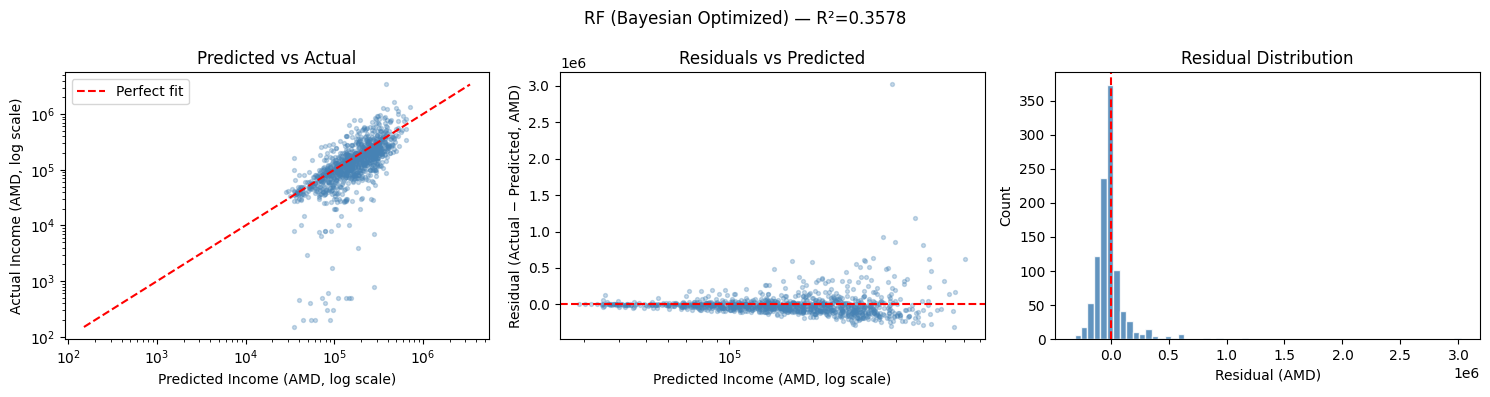

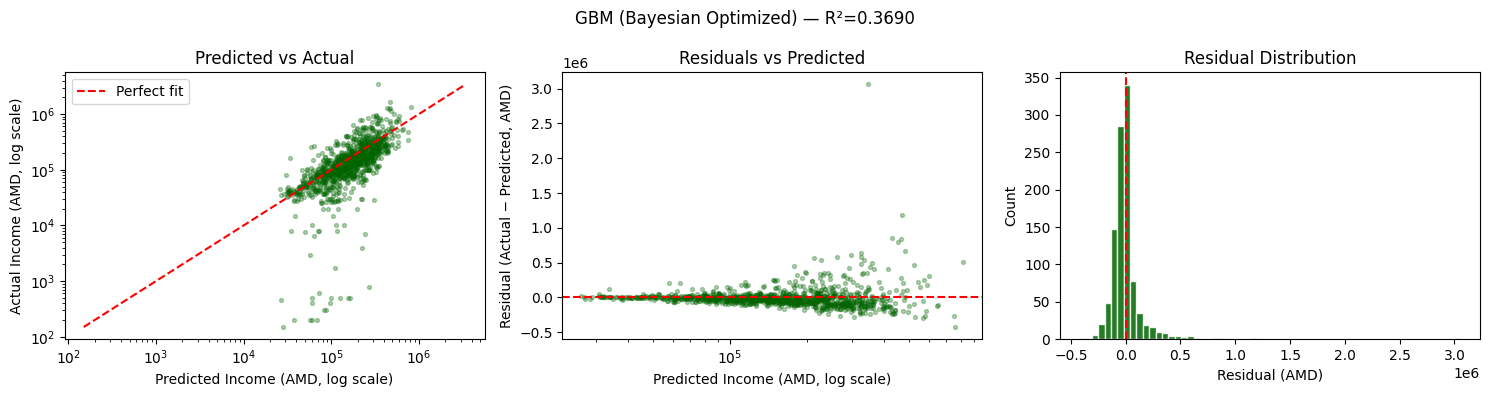

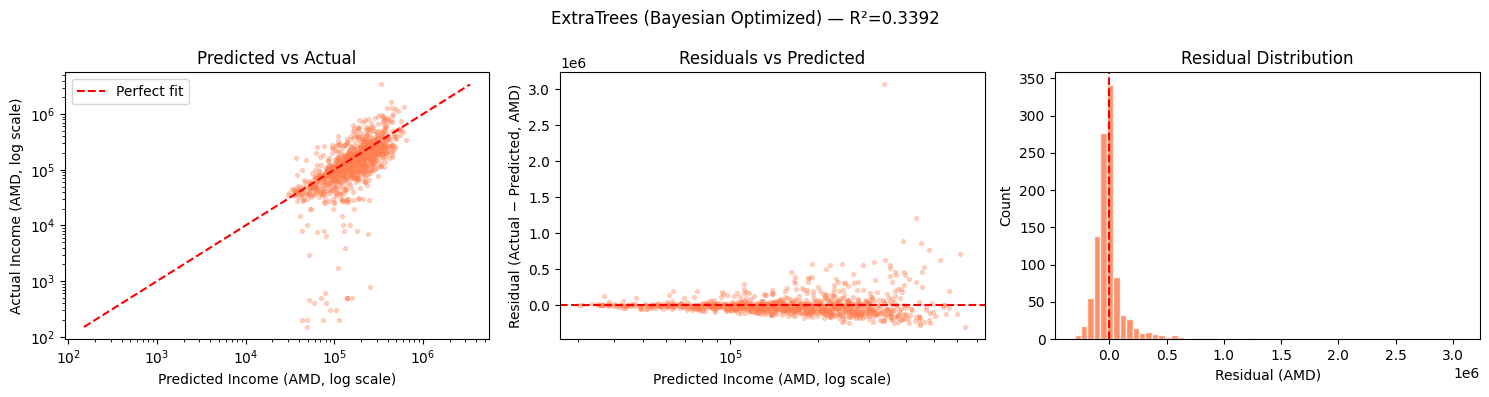

In [6]:
model_colors = {'RF': 'steelblue', 'GBM': 'darkgreen', 'ExtraTrees': 'coral'}

for name, model in BEST_MODELS.items():
    y_pred = model.predict(X_test_s)
    residuals = y_test.values - y_pred
    r2 = MODEL_METRICS[name]['R2']
    c = model_colors[name]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{name} (Bayesian Optimized) — R²={r2:.4f}', fontsize=12)

    # Predicted vs Actual
    axes[0].scatter(y_pred, y_test.values, alpha=0.3, s=8, c=c)
    mn, mx = min(y_pred.min(), y_test.min()), max(y_pred.max(), y_test.max())
    axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    axes[0].set_xscale('log'); axes[0].set_yscale('log')
    axes[0].set_xlabel('Predicted Income (AMD, log scale)')
    axes[0].set_ylabel('Actual Income (AMD, log scale)')
    axes[0].set_title('Predicted vs Actual')
    axes[0].legend()

    # Residuals vs Predicted
    axes[1].scatter(y_pred, residuals, alpha=0.3, s=8, c=c)
    axes[1].axhline(0, color='red', lw=1.5, ls='--')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Predicted Income (AMD, log scale)')
    axes[1].set_ylabel('Residual (Actual − Predicted, AMD)')
    axes[1].set_title('Residuals vs Predicted')

    # Residual distribution
    axes[2].hist(residuals, bins=60, color=c, edgecolor='white', alpha=0.85)
    axes[2].axvline(0, color='red', lw=1.5, ls='--')
    axes[2].set_xlabel('Residual (AMD)')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Residual Distribution')

    plt.tight_layout()
    plt.savefig(OUT_DIR / f'residuals_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Unified normalized feature importance comparison

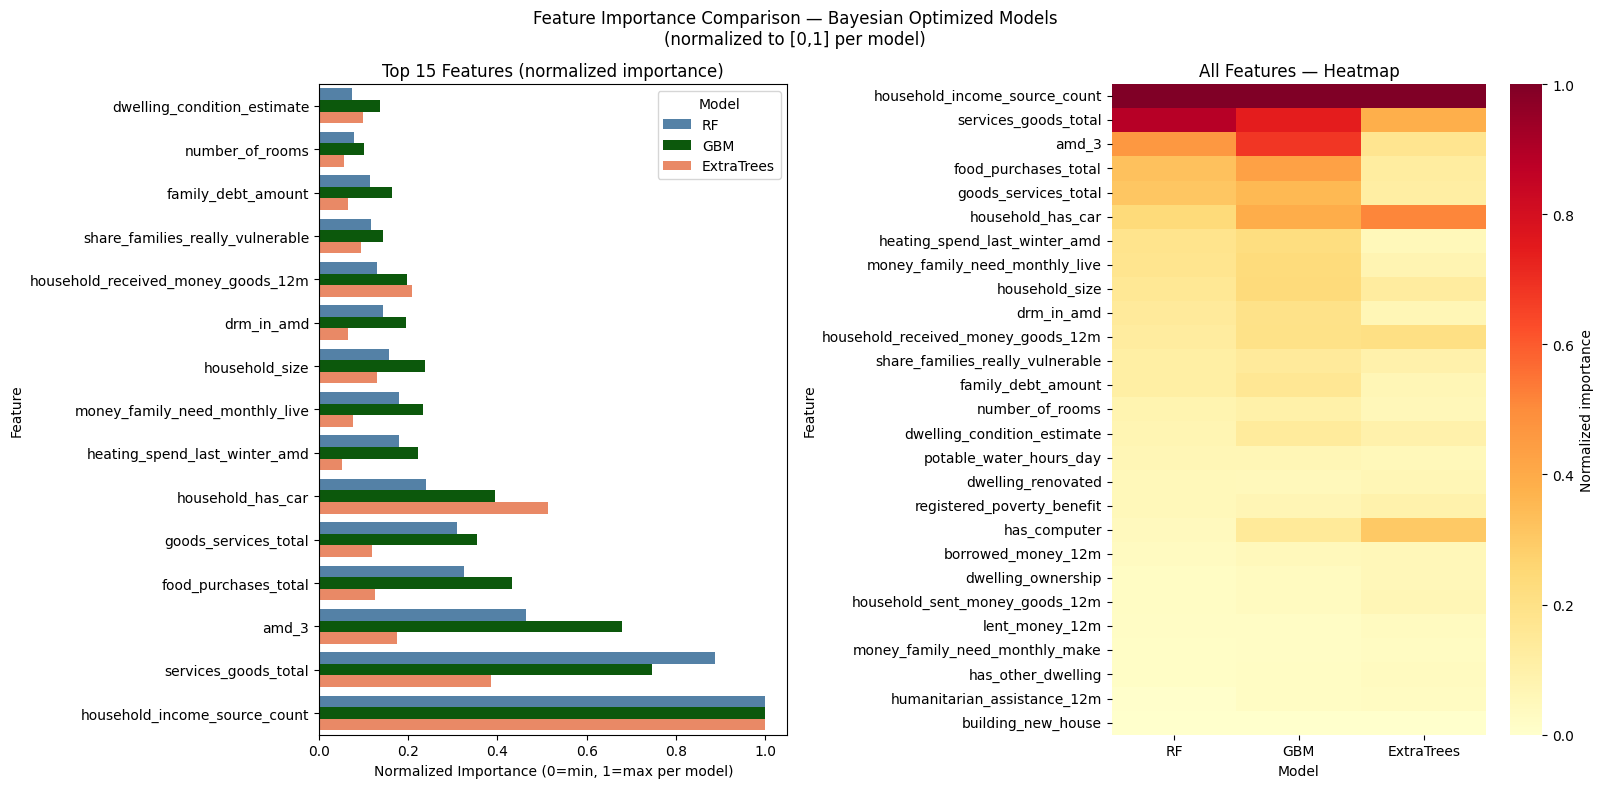

Outputs saved to: /Users/hovosukiasyan/Capstone/data/ilcs/research/bayesian_opt


In [7]:
# Build normalized importance DataFrame
imp_dfs = []
for name, imp_arr in IMPORTANCES.items():
    norm = imp_arr / imp_arr.max()
    imp_dfs.append(pd.DataFrame({'feature': feature_cols, 'importance': norm, 'model': name}))
imp_all = pd.concat(imp_dfs, ignore_index=True)

# Sort features by RF importance
rf_order = imp_all[imp_all['model'] == 'RF'].sort_values('importance', ascending=False)['feature'].tolist()

# Top 15 features
top15 = rf_order[:15]
plot_df = imp_all[imp_all['feature'].isin(top15)].copy()
plot_df['feature'] = pd.Categorical(plot_df['feature'], categories=top15[::-1], ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Feature Importance Comparison — Bayesian Optimized Models\n(normalized to [0,1] per model)', fontsize=12)

# Grouped bar chart
sns.barplot(data=plot_df, x='importance', y='feature', hue='model', ax=axes[0],
            palette={'RF': 'steelblue', 'GBM': 'darkgreen', 'ExtraTrees': 'coral'})
axes[0].set_title('Top 15 Features (normalized importance)')
axes[0].set_xlabel('Normalized Importance (0=min, 1=max per model)')
axes[0].set_ylabel('Feature')
axes[0].legend(title='Model')

# Heatmap — all features
hm_df = pd.DataFrame(IMPORTANCES, index=feature_cols)
hm_df = hm_df.div(hm_df.max()).loc[rf_order]
sns.heatmap(hm_df, annot=False, cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Normalized importance'})
axes[1].set_title('All Features — Heatmap')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Save importances
hm_df.to_csv(OUT_DIR / 'feature_importance_normalized.csv')
print(f'Outputs saved to: {OUT_DIR}')

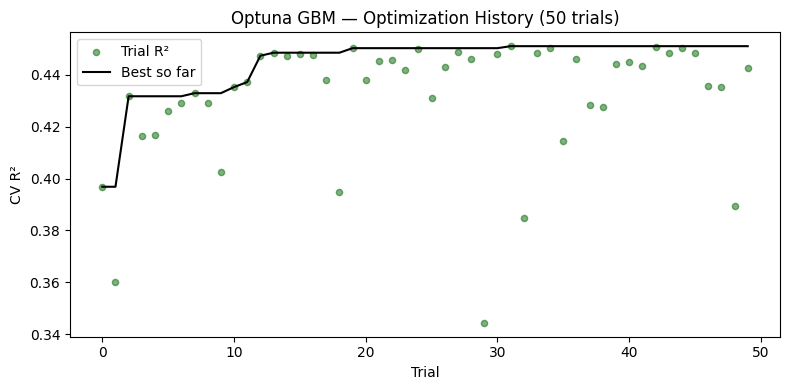

Saved to: /Users/hovosukiasyan/Capstone/data/ilcs/research/bayesian_opt/optuna-gb-history.png


In [8]:
trials = study_gbm.trials
trial_nums = [t.number for t in trials]
trial_vals = [t.value for t in trials]
best_so_far = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(trial_nums, trial_vals, alpha=0.5, s=20, label='Trial R²', color='darkgreen')
ax.plot(trial_nums, best_so_far, color='black', linewidth=1.5, label='Best so far')
ax.set_xlabel('Trial')
ax.set_ylabel('CV R²')
ax.set_title('Optuna GBM — Optimization History (50 trials)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'optuna-gb-history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to:', OUT_DIR / 'optuna-gb-history.png')